# HW05 — Логистическая регрессия + бейзлайн (DummyClassifier)

Цель: предсказать `default` (0/1) по синтетическим признакам клиентов.

План:
1) Загрузка данных и первичный анализ  
2) Подготовка `X`, `y`  
3) Train/Test split + Dummy baseline  
4) LogisticRegression + подбор `C`  
5) ROC-кривая и сохранение графика  
6) Сравнение моделей + текстовые выводы

In [2]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
)

import matplotlib.pyplot as plt


In [20]:
# Основной путь по репо
data_path = os.path.join("seminars", "S05", "S05-hw-dataset.csv")

# Fallback на случай, если ноутбук запускается из другой рабочей директории
fallback_path = os.path.join("..", "..", "seminars", "S05", "S05-hw-dataset.csv")

if os.path.exists(data_path):
    csv_path = data_path
elif os.path.exists(fallback_path):
    csv_path = fallback_path
else:
    raise FileNotFoundError(
        "Не найден CSV. Проверьте, что файл лежит в seminars/S05/S05-hw-dataset.csv "
        "и что вы запускаете ноутбук из корня репозитория или из homeworks/HW05/."
    )

df = pd.read_csv(csv_path)
df.head()


,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
0,1,25,94074,22,839,0.547339,1,7,0,0,26057,5229,0.080052,19,1,8,0
1,2,58,51884,26,565,0.290882,1,1,0,1,16221,11595,0.428311,15,0,7,0
2,3,53,48656,39,561,0.522340,1,13,0,0,55448,-2947,0.770883,15,4,5,0
3,4,42,81492,30,582,0.709123,2,10,1,1,35188,17727,0.357619,0,2,7,1
4,5,42,94713,8,642,0.793392,3,3,0,0,0,-404,0.414260,17,1,10,1


In [4]:
print("Shape:", df.shape)
display(df.head())

df.info()


Shape: (3000, 17)


,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
0,1,25,94074,22,839,0.547339,1,7,0,0,26057,5229,0.080052,19,1,8,0
1,2,58,51884,26,565,0.290882,1,1,0,1,16221,11595,0.428311,15,0,7,0
2,3,53,48656,39,561,0.522340,1,13,0,0,55448,-2947,0.770883,15,4,5,0
3,4,42,81492,30,582,0.709123,2,10,1,1,35188,17727,0.357619,0,2,7,1
4,5,42,94713,8,642,0.793392,3,3,0,0,0,-404,0.414260,17,1,10,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   client_id                       3000 non-null   int64  
 1   age                             3000 non-null   int64  
 2   income                          3000 non-null   int64  
 3   years_employed                  3000 non-null   int64  
 4   credit_score                    3000 non-null   int64  
 5   debt_to_income                  3000 non-null   float64
 6   num_credit_cards                3000 non-null   int64  
 7   num_late_payments               3000 non-null   int64  
 8   has_mortgage                    3000 non-null   int64  
 9   has_car_loan                    3000 non-null   int64  
 10  savings_balance                 3000 non-null   int64  
 11  checking_balance                3000 non-null   int64  
 12  region_risk_score               30

In [5]:
display(df.describe())

target_col = "default"
print("\nTarget distribution (counts):")
print(df[target_col].value_counts())

print("\nTarget distribution (share):")
print(df[target_col].value_counts(normalize=True).round(4))


,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,45.059667,69658.992000,19.577667,649.285333,0.284065,3.494667,6.869333,0.495000,0.501333,20607.256667,5559.684333,0.400175,9.524667,1.976333,6.968667,0.410333
std,866.169729,14.192883,24742.235182,11.381497,69.955852,0.161112,2.289917,4.291278,0.500058,0.500082,14035.209739,6306.032612,0.204529,5.779030,1.408700,4.349942,0.491976
min,1.000000,21.000000,15000.000000,0.000000,402.000000,0.006147,0.000000,0.000000,0.000000,0.000000,0.000000,-3000.000000,0.001148,0.000000,0.000000,0.000000,0.000000
25%,750.750000,33.000000,52641.750000,10.000000,604.000000,0.157796,1.000000,3.000000,0.000000,0.000000,9612.250000,341.500000,0.239208,5.000000,1.000000,3.000000,0.000000
50%,1500.500000,45.000000,69784.500000,20.000000,647.000000,0.261726,3.000000,7.000000,0.000000,1.000000,20021.000000,5114.500000,0.381992,10.000000,2.000000,7.000000,0.000000
75%,2250.250000,57.000000,85874.250000,29.000000,697.000000,0.388886,6.000000,10.000000,1.000000,1.000000,30101.250000,9906.250000,0.549213,15.000000,3.000000,11.000000,1.000000
max,3000.000000,69.000000,156351.000000,39.000000,850.000000,0.878343,7.000000,14.000000,1.000000,1.000000,75237.000000,29335.000000,0.961733,19.000000,4.000000,14.000000,1.000000



Target distribution (counts):
default
0    1769
1    1231
Name: count, dtype: int64

Target distribution (share):
default
0    0.5897
1    0.4103
Name: proportion, dtype: float64


## Наблюдения по данным (коротко)

- Размер датасета: 3000 наблюдений и 17 столбцов, из которых 1 — целевой признак.
- Все признаки являются числовыми (целые и вещественные), пропущенных значений нет.
- Диапазоны признаков выглядят разумными:  
  возраст от 21 до 69 лет, кредитный скор от ~400 до 850, отношение долгов к доходу лежит в диапазоне [0, 1].
- В данных присутствуют допустимые, но потенциально информативные значения, например отрицательный баланс на расчётном счёте.
- Целевой признак `default` распределён умеренно несбалансированно:  
  около 59% наблюдений — класс 0 (нет дефолта) и 41% — класс 1 (дефолт).


In [6]:
# Таргет
y = df["default"]

# Признаки: всё кроме default и client_id (ID не используем)
drop_cols = ["default"]
if "client_id" in df.columns:
    drop_cols.append("client_id")

X = df.drop(columns=drop_cols)

# Проверим, что все признаки числовые
non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
print("Non-numeric columns:", non_numeric)

# Быстрая проверка диапазона debt_to_income, если есть
if "debt_to_income" in X.columns:
    print("debt_to_income min/max:", X["debt_to_income"].min(), X["debt_to_income"].max())

X.head()


Non-numeric columns: []
debt_to_income min/max: 0.0061471149847966 0.878343349584274


,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years
0,25,94074,22,839,0.547339,1,7,0,0,26057,5229,0.080052,19,1,8
1,58,51884,26,565,0.290882,1,1,0,1,16221,11595,0.428311,15,0,7
2,53,48656,39,561,0.522340,1,13,0,0,55448,-2947,0.770883,15,4,5
3,42,81492,30,582,0.709123,2,10,1,1,35188,17727,0.357619,0,2,7
4,42,94713,8,642,0.793392,3,3,0,0,0,-404,0.414260,17,1,10


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train target share:\n", y_train.value_counts(normalize=True).round(4))
print("Test target share:\n", y_test.value_counts(normalize=True).round(4))


Train shape: (2250, 15) Test shape: (750, 15)
Train target share:
 default
0    0.5898
1    0.4102
Name: proportion, dtype: float64
Test target share:
 default
0    0.5893
1    0.4107
Name: proportion, dtype: float64


In [19]:
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

y_proba_dummy = dummy.predict_proba(X_test)[:, 1]

acc_dummy = accuracy_score(y_test, y_pred_dummy)
auc_dummy = roc_auc_score(y_test, y_proba_dummy)

print("DummyClassifier metrics:")
print("Accuracy:", round(acc_dummy, 4))
print("ROC-AUC:", round(auc_dummy, 4))


DummyClassifier metrics:
Accuracy: 0.5893
ROC-AUC: 0.5


## Комментарий про бейзлайн

`DummyClassifier(strategy="most_frequent")` всегда предсказывает самый частый класс из train.
Это даёт точку отсчёта: если “умная” модель не лучше, значит она не извлекает полезный сигнал из признаков.


In [9]:
C_values = [0.01, 0.1, 1.0, 10.0, 100.0]

results = []

for C in C_values:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(C=C, max_iter=2000, random_state=42))
    ])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append({"model": f"LogReg (C={C})", "C": C, "accuracy": acc, "roc_auc": auc})

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
results_df


,model,C,accuracy,roc_auc
4,LogReg (C=100.0),100.00,0.793333,0.864731
3,LogReg (C=10.0),10.00,0.793333,0.864724
2,LogReg (C=1.0),1.00,0.793333,0.864709
1,LogReg (C=0.1),0.10,0.797333,0.864672
0,LogReg (C=0.01),0.01,0.797333,0.864275


In [10]:
best_row = results_df.iloc[0]
best_C = best_row["C"]
print("Best C:", best_C)

best_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(C=best_C, max_iter=2000, random_state=42))
])

best_model.fit(X_train, y_train)

y_pred_lr = best_model.predict(X_test)
y_proba_lr = best_model.predict_proba(X_test)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

print("Logistic Regression (best) metrics:")
print("Accuracy:", round(acc_lr, 4))
print("ROC-AUC:", round(auc_lr, 4))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification report:")
print(classification_report(y_test, y_pred_lr, digits=4))


Best C: 100.0
Logistic Regression (best) metrics:
Accuracy: 0.7933
ROC-AUC: 0.8647

Confusion matrix:
[[382  60]
 [ 95 213]]

Classification report:
              precision    recall  f1-score   support

           0     0.8008    0.8643    0.8313       442
           1     0.7802    0.6916    0.7332       308

    accuracy                         0.7933       750
   macro avg     0.7905    0.7779    0.7823       750
weighted avg     0.7924    0.7933    0.7910       750



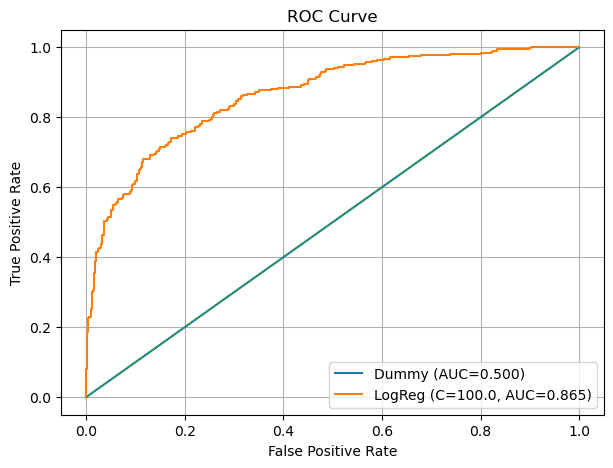

Saved: homeworks\HW05\figures\roc_curve.png


In [18]:
fpr_dummy, tpr_dummy, _ = roc_curve(y_test, y_proba_dummy)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)

plt.figure(figsize=(7, 5))
plt.plot(fpr_dummy, tpr_dummy, label=f"Dummy (AUC={auc_dummy:.3f})")
plt.plot(fpr_lr, tpr_lr, label=f"LogReg (C={best_C}, AUC={auc_lr:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)

# Путь сохранения
fig_dir = os.path.join("homeworks", "HW05", "figures")
os.makedirs(fig_dir, exist_ok=True)

fig_path = os.path.join(fig_dir, "roc_curve.png")
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)


In [12]:
summary = pd.DataFrame([
    {"model": "DummyClassifier (most_frequent)", "accuracy": acc_dummy, "roc_auc": auc_dummy},
    {"model": f"LogisticRegression (C={best_C})", "accuracy": acc_lr, "roc_auc": auc_lr},
]).set_index("model")

summary


,accuracy,roc_auc
model,,
DummyClassifier (most_frequent),0.589333,0.500000
LogisticRegression (C=100.0),0.793333,0.864731


## 2.4.1. Дополнительные метрики и PR-кривая

В задачах кредитного скоринга важно не только общее качество (ROC-AUC),
но и баланс между precision и recall для класса дефолта.
Поэтому дополнительно рассмотрим PR-кривую и Average Precision.

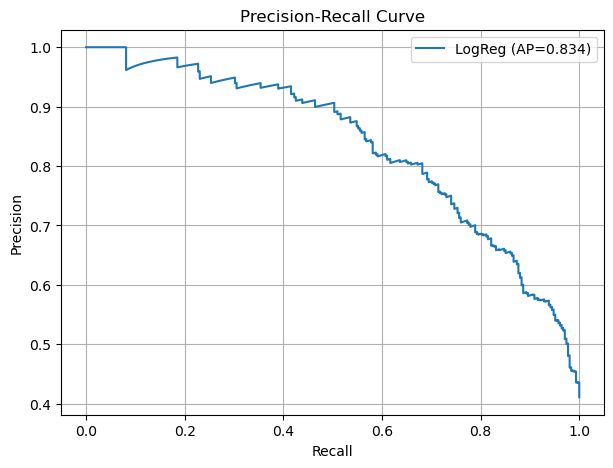

Average Precision: 0.8344


In [13]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_proba_lr)
ap_score = average_precision_score(y_test, y_proba_lr)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"LogReg (AP={ap_score:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

print("Average Precision:", round(ap_score, 4))


PR-кривая показывает компромисс между полнотой и точностью для класса дефолта.
Значение Average Precision заметно выше случайного уровня,
что указывает на способность модели выделять клиентов с высоким риском дефолта.


In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds_to_check = [0.3, 0.5, 0.7]

rows = []

for t in thresholds_to_check:
    y_pred_t = (y_proba_lr >= t).astype(int)
    rows.append({
        "threshold": t,
        "precision": precision_score(y_test, y_pred_t),
        "recall": recall_score(y_test, y_pred_t),
        "f1": f1_score(y_test, y_pred_t),
    })

pd.DataFrame(rows)


,threshold,precision,recall,f1
0,0.3,0.659091,0.847403,0.741477
1,0.5,0.780220,0.691558,0.733219
2,0.7,0.874346,0.542208,0.669339


При уменьшении порога увеличивается recall для дефолтов,
но падает precision. Это типичный и ожидаемый компромисс.

Выбор порога зависит от бизнес-задачи:
например, банк может предпочесть выше recall,
чтобы реже пропускать потенциальных дефолтных клиентов.

## 2.4.2. Калибровка вероятностей

ROC-AUC показывает качество ранжирования,
но не гарантирует, что предсказанные вероятности являются хорошо откалиброванными.
Проверим и улучшим калибровку модели.

In [15]:
from sklearn.calibration import CalibratedClassifierCV

# Базовая логистическая регрессия (без pipeline, scaler уже внутри)
base_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(C=best_C, max_iter=2000, random_state=42))
])

calibrated_lr = CalibratedClassifierCV(
    base_lr,
    method="sigmoid",
    cv=5
)

calibrated_lr.fit(X_train, y_train)

y_proba_calibrated = calibrated_lr.predict_proba(X_test)[:, 1]


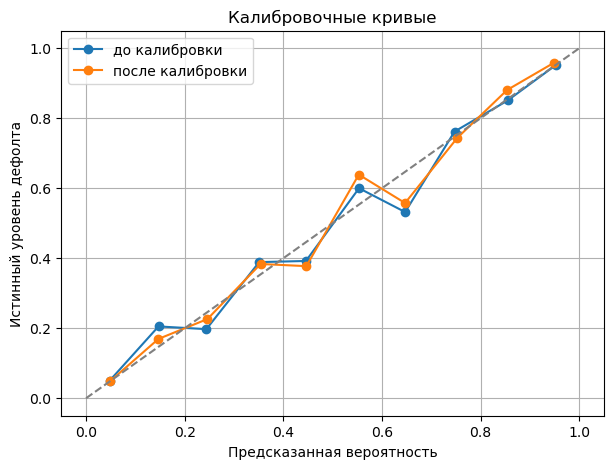

In [17]:
from sklearn.calibration import calibration_curve

prob_true_lr, prob_pred_lr = calibration_curve(
    y_test, y_proba_lr, n_bins=10
)

prob_true_cal, prob_pred_cal = calibration_curve(
    y_test, y_proba_calibrated, n_bins=10
)

plt.figure(figsize=(7, 5))
plt.plot(prob_pred_lr, prob_true_lr, marker="o", label="до калибровки")
plt.plot(prob_pred_cal, prob_true_cal, marker="o", label="после калибровки")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("Предсказанная вероятность")
plt.ylabel("Истинный уровень дефолта")
plt.title("Калибровочные кривые")
plt.legend()
plt.grid(True)
plt.show()


Калибровочная кривая показывает,
насколько предсказанные вероятности соответствуют реальной частоте дефолтов.

После калибровки точки располагаются ближе к диагонали,
что означает более «честные» и интерпретируемые вероятностные прогнозы.
Это особенно важно в практических кредитных сценариях.

## Выводы (отчёт)

1. Бейзлайн-модель `DummyClassifier(strategy="most_frequent")` показала Accuracy ≈ 0.589 и ROC-AUC = 0.50, что соответствует случайному угадыванию и отражает умеренный дисбаланс классов.
2. Логистическая регрессия со стандартизацией признаков значительно превосходит бейзлайн:  
   Accuracy ≈ 0.793, ROC-AUC ≈ 0.865.
3. Перебор параметра регуляризации `C` показал, что качество модели меняется незначительно, однако наилучший результат по ROC-AUC был достигнут при C = 100.
4. Это говорит о том, что для данного датасета слабая регуляризация оказывается предпочтительной и модель не склонна к сильному переобучению.
5. Анализ confusion matrix показывает, что модель хорошо распознаёт класс без дефолта и достаточно уверенно выявляет дефолты, хотя recall для класса 1 ниже, чем для класса 0.
6. ROC-кривая подтверждает, что логистическая регрессия стабильно превосходит бейзлайн по всему диапазону порогов.
7. В целом логистическая регрессия является разумным выбором для данной задачи: она проста, интерпретируема и демонстрирует существенный прирост качества по сравнению с наивной моделью.
